## Old shit

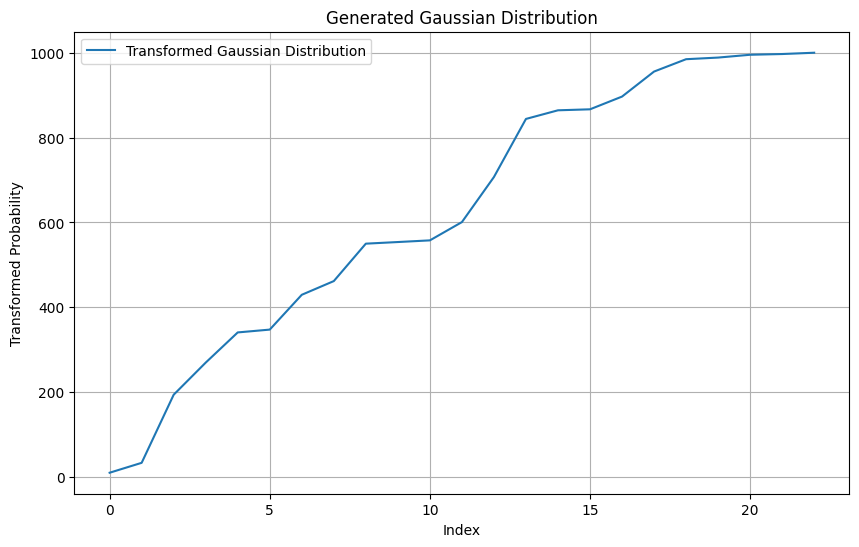

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_gaussian_probs(mu, sigma, nmb):
    x = np.random.normal(mu, sigma, nmb)
    y = (2. * np.pi * sigma ** 2.) ** -.5 * np.exp(-.5 * (x - mu) ** 2. / sigma ** 2.)
    
    # Sorting the values based on the PDF
    x, y = x[np.argsort(y)], np.sort(y)
    
    # Transform the values (for demonstration purposes, use a simple scaling)
    transformed_x = [100 - abs(i) * 100 for i in x]
    
    # Normalize the values
    rmin = min(transformed_x)
    rmax = max(transformed_x)
    tmin, tmax = 10, 1000
    probs = [((m - rmin) / (rmax - rmin)) * (tmax - tmin) + tmin for m in transformed_x]

    return probs


# Parameters for the distribution
mu = 0  # Mean
sigma = 0.4  # Standard deviation
nmb = 23  # Number of points

# Generate the Gaussian probabilities
probs = generate_gaussian_probs(mu, sigma, nmb)

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.plot(probs, label='Transformed Gaussian Distribution')
plt.title('Generated Gaussian Distribution')
plt.xlabel('Index')
plt.ylabel('Transformed Probability')
plt.grid(True)
plt.legend()
plt.show()

## Proper gaussian

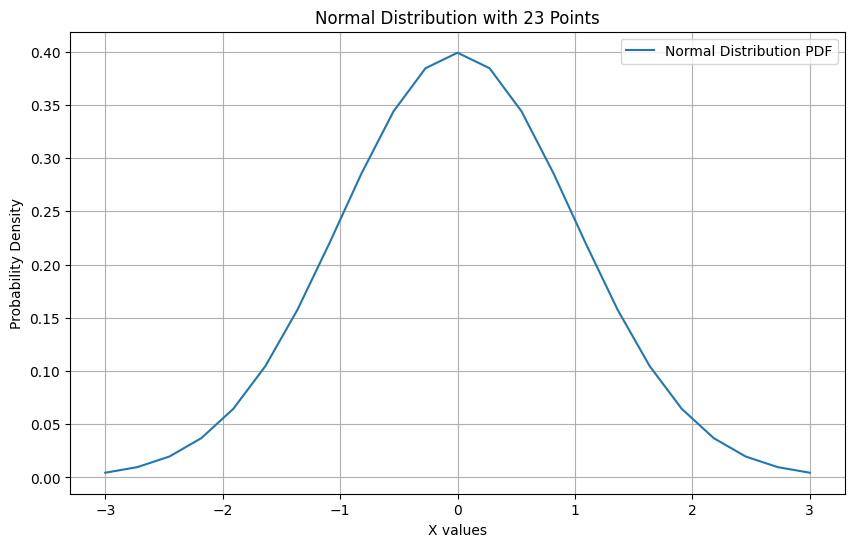

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu = 0  # Mean
sigma = 1  # Standard deviation
nmb = 23  # Number of points

# Generate nmb points from a normal distribution
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, nmb)  # Create points on the x-axis
pdf_values = norm.pdf(x, mu, sigma)  # Get the probability density for each point

# Plot the normal distribution
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_values, label='Normal Distribution PDF')
plt.title(f'Normal Distribution with {nmb} Points')
plt.xlabel('X values')
plt.ylabel('Probability Density')
plt.grid(True)
plt.legend()
plt.show()


## Custom

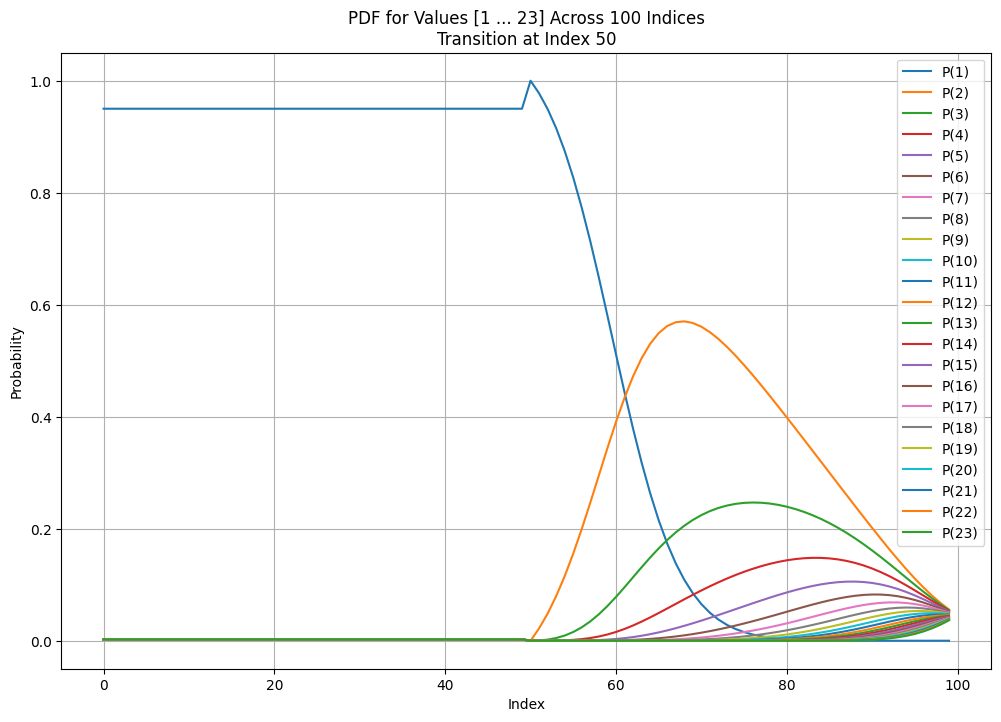

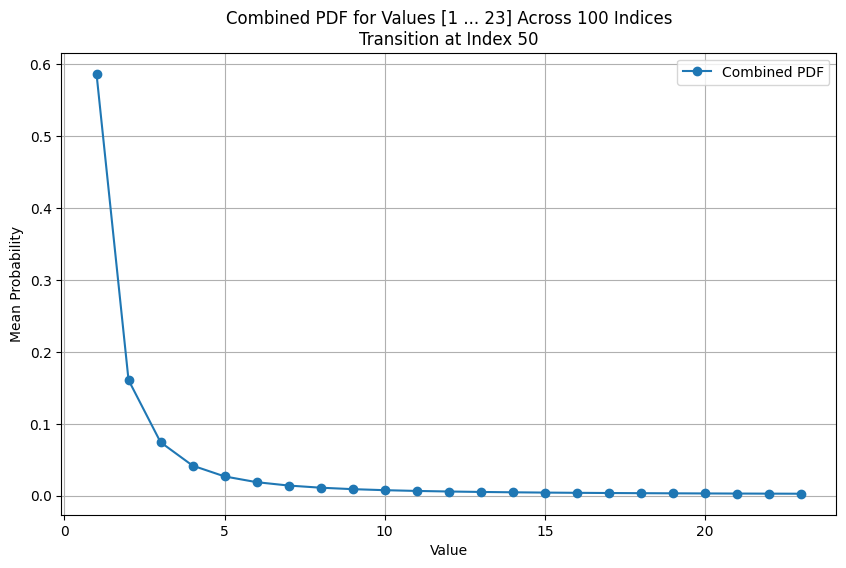

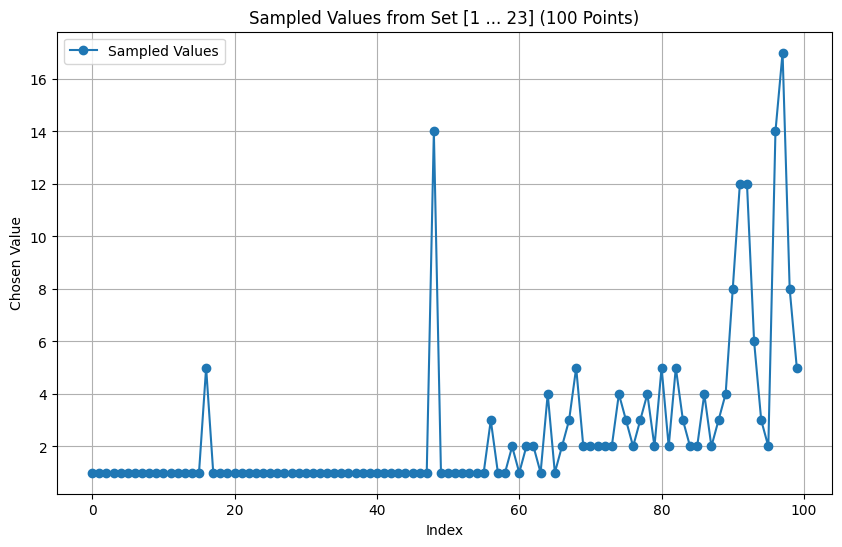

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate the combined PDF for 23 values, with the transition starting after index 50
def generate_pdf(n=100, value_set=23, transition_index=50):
    """
    Generate a PDF for `value_set` values over `n` points, with dominant P(0) in the first half.
    
    Parameters:
    n: int
        Number of points to generate the PDF for.
    value_set: int
        The number of discrete values (e.g., [1, 2, ..., value_set]).
    transition_index: int
        The index after which the probabilities of higher values start increasing.
        
    Returns:
    pdf_list: numpy.ndarray
        A 2D array representing the PDF over `n` points.
    """
    values = np.arange(1, value_set + 1)  # Values from 1 to 23
    pdf_list = []

    for i in range(n):
        scale = i / (n - 1)  # Normalize index to scale between 0 and 1

        if i < transition_index:  # For the first half, keep P(0) dominant
            probs = [0.95] + [0.05 / (value_set - 1)] * (value_set - 1)  # High P(0), low P(1), P(2), ..., P(23)
        else:
            adjusted_scale = (i - transition_index) / (n - transition_index)  # Scale after the transition point
            # Decrease P(0) and gradually increase the rest of the values
            probs = [(1 - adjusted_scale) ** 6] + [(adjusted_scale ** (v - 1)) for v in range(2, value_set + 1)]

        # Normalize probabilities
        probs = np.array(probs)
        probs /= probs.sum()

        pdf_list.append(probs)

    return np.array(pdf_list)

# Function to sample values based on the generated PDF
def sample_from_pdf(pdf, n=100, value_set=23):
    values = np.arange(1, value_set + 1)
    distribution = []

    for i in range(n):
        # Sample based on the precomputed probabilities in the pdf
        chosen_value = np.random.choice(values, p=pdf[i])
        distribution.append(chosen_value)

    return distribution

# Parameters
n = 100
value_set = 23
transition_index = 50  # Start increasing probabilities for higher values after index 50

# Generate the combined PDF for 23 values with a transition at index 50
pdf = generate_pdf(n, value_set, transition_index)

# Plot the separate distributions for each value
plt.figure(figsize=(12, 8))
for v in range(value_set):
    plt.plot(pdf[:, v], label=f'P({v+1})')

plt.title(f'PDF for Values [1 ... {value_set}] Across 100 Indices\nTransition at Index {transition_index}')
plt.xlabel('Index')
plt.ylabel('Probability')
plt.grid(True)
plt.legend()
plt.show()

# Plot the combined PDF (mean probability distribution for all indices)
mean_pdf = np.mean(pdf, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, value_set + 1), mean_pdf, label='Combined PDF', marker='o')
plt.title(f'Combined PDF for Values [1 ... {value_set}] Across 100 Indices\nTransition at Index {transition_index}')
plt.xlabel('Value')
plt.ylabel('Mean Probability')
plt.grid(True)
plt.legend()
plt.show()

# Sample 100 values based on the generated PDF
sampled_values = sample_from_pdf(pdf, n, value_set)

# Plot the sampled values
plt.figure(figsize=(10, 6))
plt.plot(sampled_values, label='Sampled Values', marker='o')
plt.title(f'Sampled Values from Set [1 ... {value_set}] ({n} Points)')
plt.xlabel('Index')
plt.ylabel('Chosen Value')
plt.grid(True)
plt.legend()
plt.show()


## Plot some PDFs

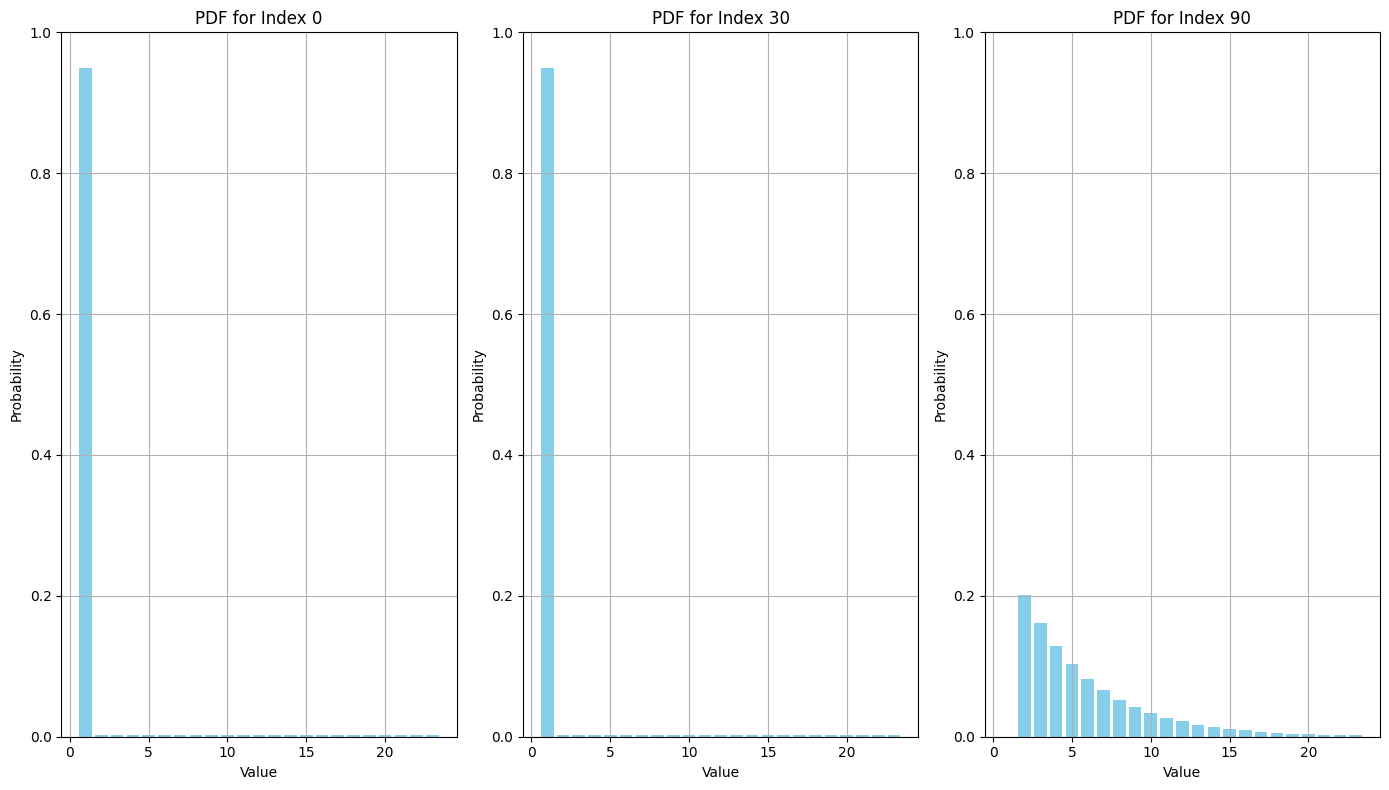

In [23]:
# Visualize the PDFs for the 0th, 30th, and 90th indices
indices_to_visualize = [0, 30, 90]
values = np.arange(1, value_set + 1)  # Values [1, 2, ..., 23]

plt.figure(figsize=(14, 8))

# Loop through the indices we want to visualize
for idx, i in enumerate(indices_to_visualize):
    pdf_at_index = pdf[i]  # Get the PDF for the specific index
    plt.subplot(1, 3, idx + 1)  # Create a subplot for each index
    plt.bar(values, pdf_at_index, color='skyblue')
    plt.title(f"PDF for Index {i}")
    plt.xlabel("Value")
    plt.ylabel("Probability")
    plt.ylim(0, 1)  # Set consistent y-axis limits for easier comparison
    plt.grid(True)

plt.tight_layout()
plt.show()

